In [1]:
import re
import json
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

import warnings

warnings.filterwarnings(
    "ignore",
    category=FutureWarning
)

In [2]:
merged_df = pd.read_csv('data_files/projection_error_uncertainty.csv')



CORRELATION ANALYSIS RESULTS (Horizon = 3 years)
Pearson Correlation Coefficient: -0.0131
Pearson p-value:                4.5606e-01 (Not Significant)
--------------------------------------------------
Spearman Rank Correlation:       0.0102
Spearman p-value:               5.5916e-01 (Not Significant)


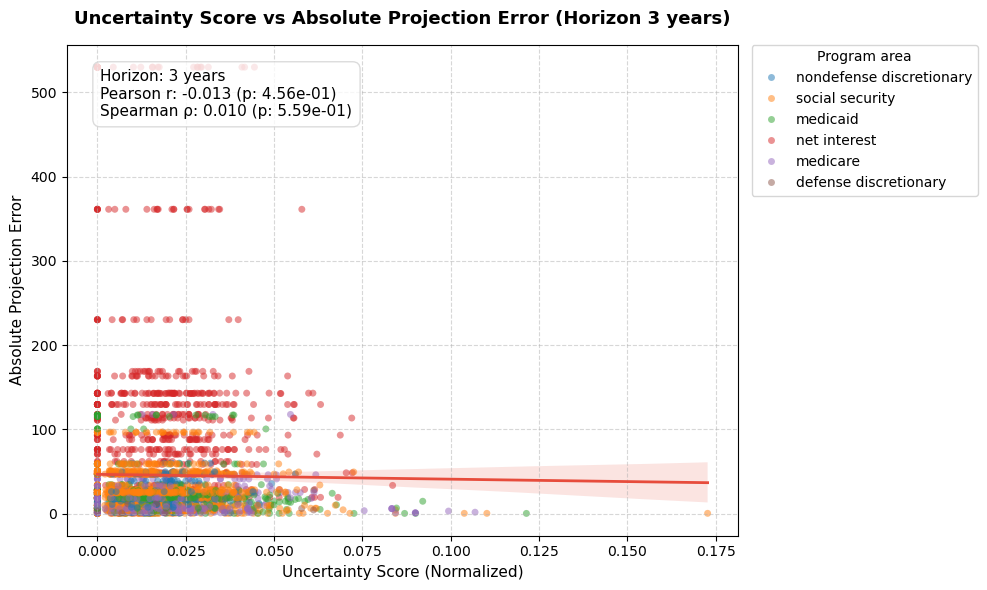

CORRELATION ANALYSIS RESULTS (Horizon = 6 years)
Pearson Correlation Coefficient: 0.0518
Pearson p-value:                5.0265e-03 (Statistically Significant)
--------------------------------------------------
Spearman Rank Correlation:       0.0404
Spearman p-value:               2.8593e-02 (Statistically Significant)


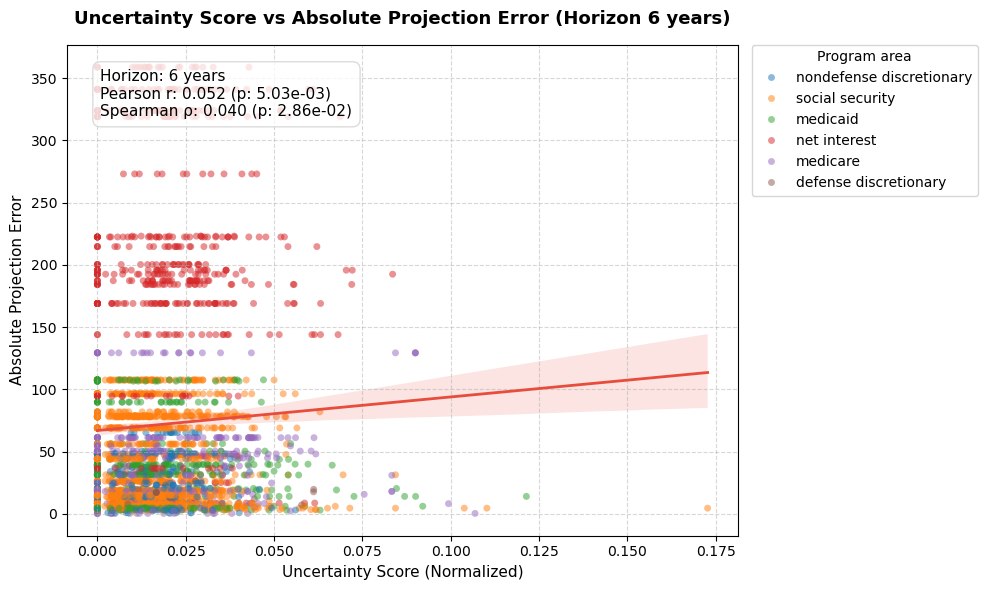

CORRELATION ANALYSIS RESULTS (Horizon = 9 years)
Pearson Correlation Coefficient: 0.0691
Pearson p-value:                4.6553e-04 (Statistically Significant)
--------------------------------------------------
Spearman Rank Correlation:       0.0940
Spearman p-value:               1.8330e-06 (Statistically Significant)


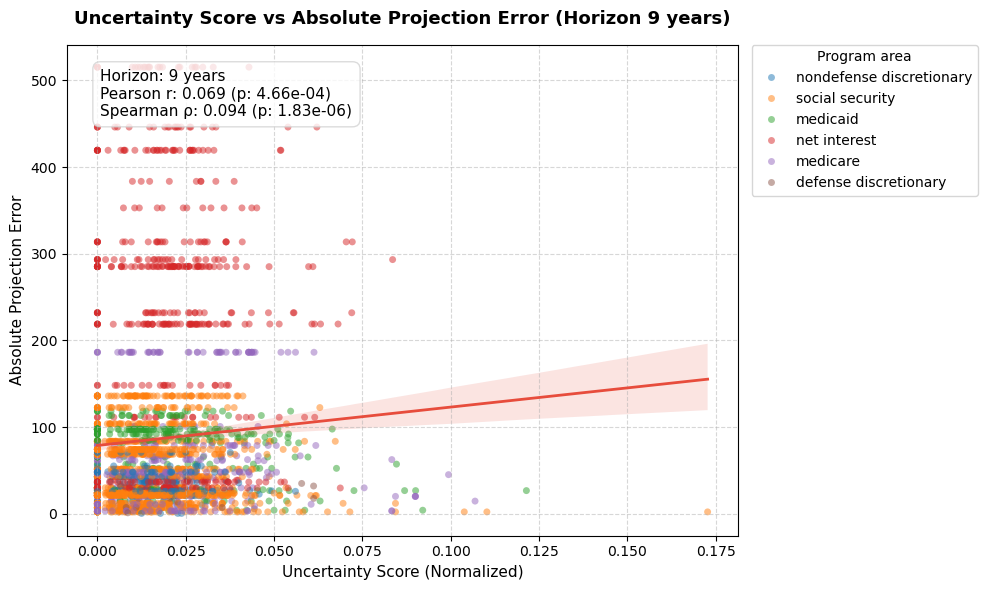

In [3]:
# ============================================================
# 1) Correlation + plots by horizon (3, 6, 9) with colors by program
# ============================================================
horizons = [3, 6, 9]

for H in horizons:

    # --- Filter to this horizon and keep subcategory for coloring ---
    clean_corr_df = merged_df.loc[
        merged_df["projection_horizon_years"].eq(H),
        ["contextual_uncertainty_score", "abs_projection_error", "subcategory"]
    ].dropna()

    # Pearson correlation (linear)
    pearson_coef, pearson_p = stats.pearsonr(
        clean_corr_df["contextual_uncertainty_score"],
        clean_corr_df["abs_projection_error"]
    )

    # Spearman correlation (rank-based)
    spearman_coef, spearman_p = stats.spearmanr(
        clean_corr_df["contextual_uncertainty_score"],
        clean_corr_df["abs_projection_error"]
    )

    # Print the results
    print("="*50)
    print(f"CORRELATION ANALYSIS RESULTS (Horizon = {H} years)")
    print("="*50)
    print(f"Pearson Correlation Coefficient: {pearson_coef:.4f}")
    print(f"Pearson p-value:                {pearson_p:.4e} ({'Statistically Significant' if pearson_p < 0.05 else 'Not Significant'})")
    print("-"*50)
    print(f"Spearman Rank Correlation:       {spearman_coef:.4f}")
    print(f"Spearman p-value:               {spearman_p:.4e} ({'Statistically Significant' if spearman_p < 0.05 else 'Not Significant'})")
    print("="*50)

    # --- Plot ---
    plt.figure(figsize=(10, 6))

    # Points colored by program area
    sns.scatterplot(
        data=clean_corr_df,
        x="contextual_uncertainty_score",
        y="abs_projection_error",
        hue="subcategory",
        alpha=0.5,
        s=25,
        linewidth=0
    )

    # Overall regression line (single line across all subcategories)
    sns.regplot(
        data=clean_corr_df,
        x="contextual_uncertainty_score",
        y="abs_projection_error",
        scatter=False,
        line_kws={"color": "#e74c3c", "linewidth": 2}
    )

    # Annotate the plot with correlation values
    stats_text = (
        f"Horizon: {H} years\n"
        f"Pearson r: {pearson_coef:.3f} (p: {pearson_p:.2e})\n"
        f"Spearman ρ: {spearman_coef:.3f} (p: {spearman_p:.2e})"
    )
    plt.gca().text(
        0.05, 0.95, stats_text,
        transform=plt.gca().transAxes,
        fontsize=11,
        verticalalignment="top",
        bbox=dict(boxstyle="round,pad=0.5", facecolor="white", alpha=0.8, edgecolor="lightgray")
    )

    plt.title(
        f"Uncertainty Score vs Absolute Projection Error (Horizon {H} years)",
        fontsize=13,
        fontweight="bold",
        pad=15
    )
    plt.xlabel("Uncertainty Score (Normalized)", fontsize=11)
    plt.ylabel("Absolute Projection Error", fontsize=11)
    plt.grid(True, linestyle="--", alpha=0.5)

    # Put legend outside to avoid covering points
    plt.legend(title="Program area", bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0)

    plt.tight_layout()
    plt.show() 

In [6]:
import numpy as np
import pandas as pd
import scipy.stats as stats

df = clean_corr_df.copy()

# 1) BETWEEN-program correlation: correlate program means
prog_means = (
    df.groupby("subcategory", as_index=False)
      .agg(
          mean_uncertainty=("contextual_uncertainty_score", "mean"),
          mean_abs_error=("abs_projection_error", "mean"),
          n=("abs_projection_error", "size")
      )
)

between_rho, between_p = stats.spearmanr(prog_means["mean_uncertainty"], prog_means["mean_abs_error"])
between_r, between_p2 = stats.pearsonr(prog_means["mean_uncertainty"], prog_means["mean_abs_error"])

print("\n--- BETWEEN-program (using program means) ---")
print(prog_means.sort_values("mean_abs_error", ascending=False).to_string(index=False))
print(f"Between Spearman ρ: {between_rho:.3f} (p={between_p:.2e})")
print(f"Between Pearson r:  {between_r:.3f} (p={between_p2:.2e})")

# 2) WITHIN-program correlation: remove each program’s mean (demean) and correlate residuals
df["u_within"] = df["contextual_uncertainty_score"] - df.groupby("subcategory")["contextual_uncertainty_score"].transform("mean")
df["e_within"] = df["abs_projection_error"] - df.groupby("subcategory")["abs_projection_error"].transform("mean")

within_rho, within_p = stats.spearmanr(df["u_within"], df["e_within"])
within_r, within_p2 = stats.pearsonr(df["u_within"], df["e_within"])

print("\n--- WITHIN-program (demeaned within subcategory) ---")
print(f"Within Spearman ρ: {within_rho:.3f} (p={within_p:.2e})")
print(f"Within Pearson r:  {within_r:.3f} (p={within_p2:.2e})")


--- BETWEEN-program (using program means) ---
             subcategory  mean_uncertainty  mean_abs_error    n
            net interest          0.021398      240.209051  471
                medicaid          0.021975       74.889059  287
                medicare          0.021030       61.918947  357
         social security          0.015085       47.504524 1228
nondefense discretionary          0.016431       34.204440  200
   defense discretionary          0.023787       22.241955   22
Between Spearman ρ: 0.029 (p=9.57e-01)
Between Pearson r:  0.218 (p=6.78e-01)

--- WITHIN-program (demeaned within subcategory) ---
Within Spearman ρ: -0.001 (p=9.66e-01)
Within Pearson r:  -0.023 (p=2.47e-01)


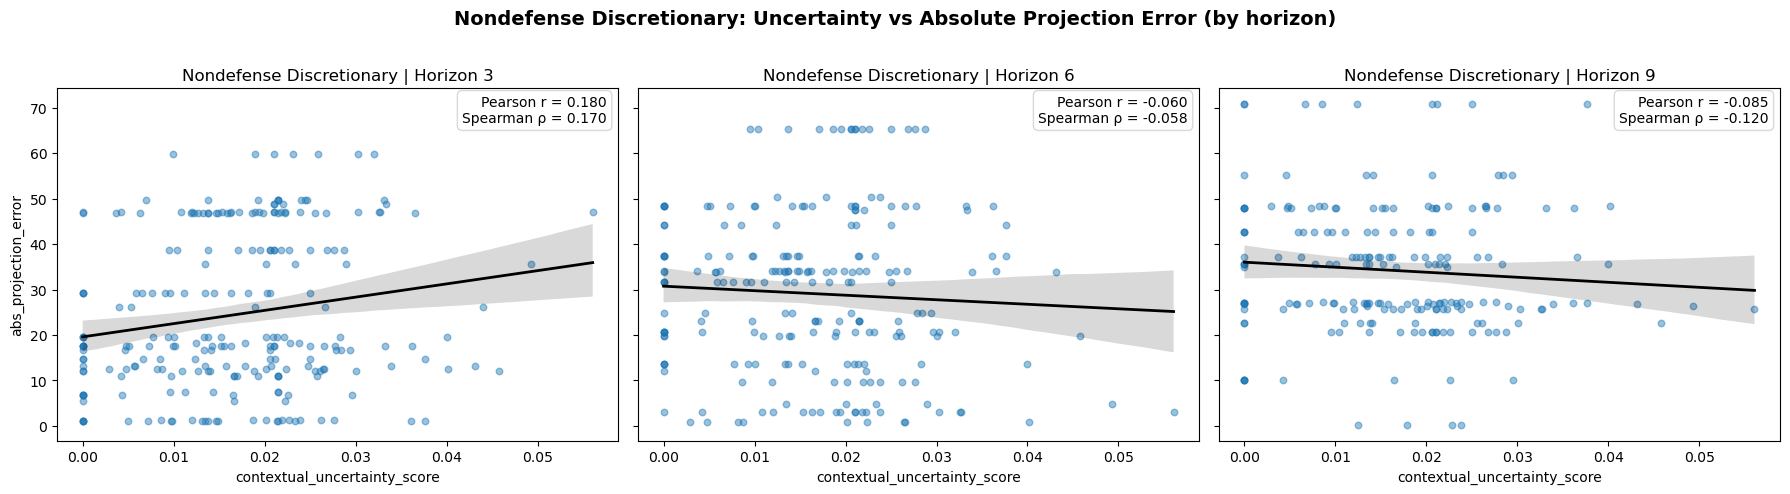

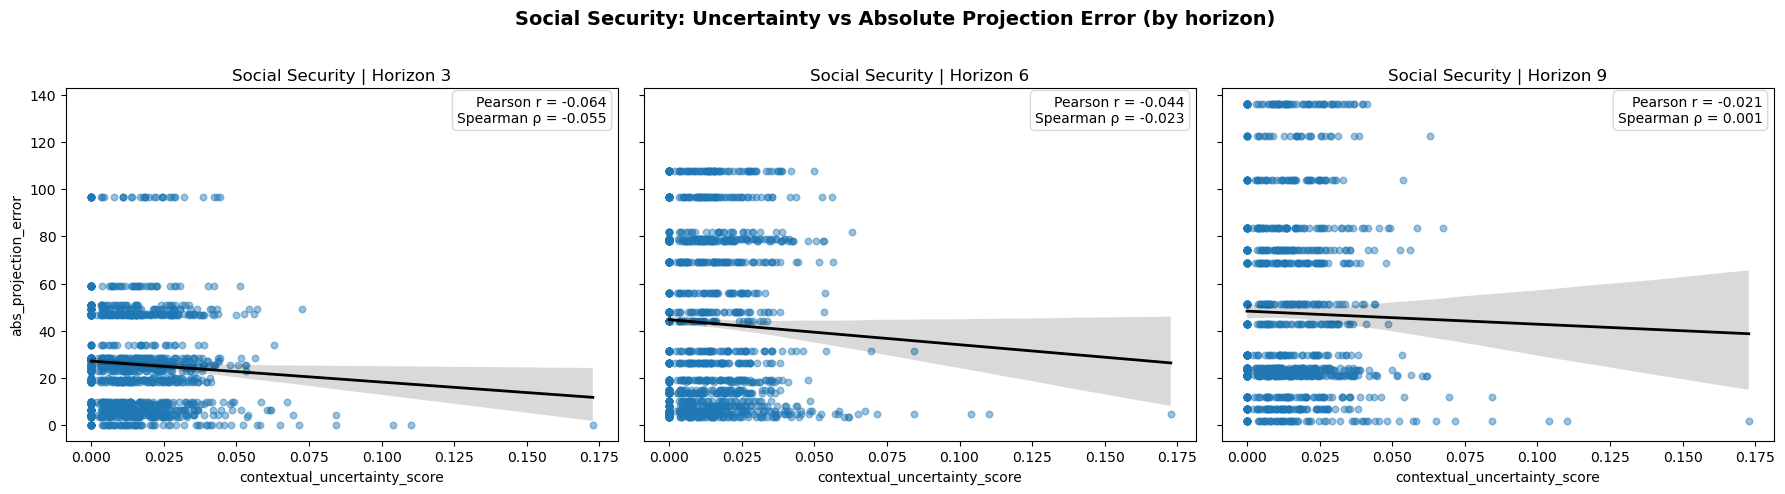

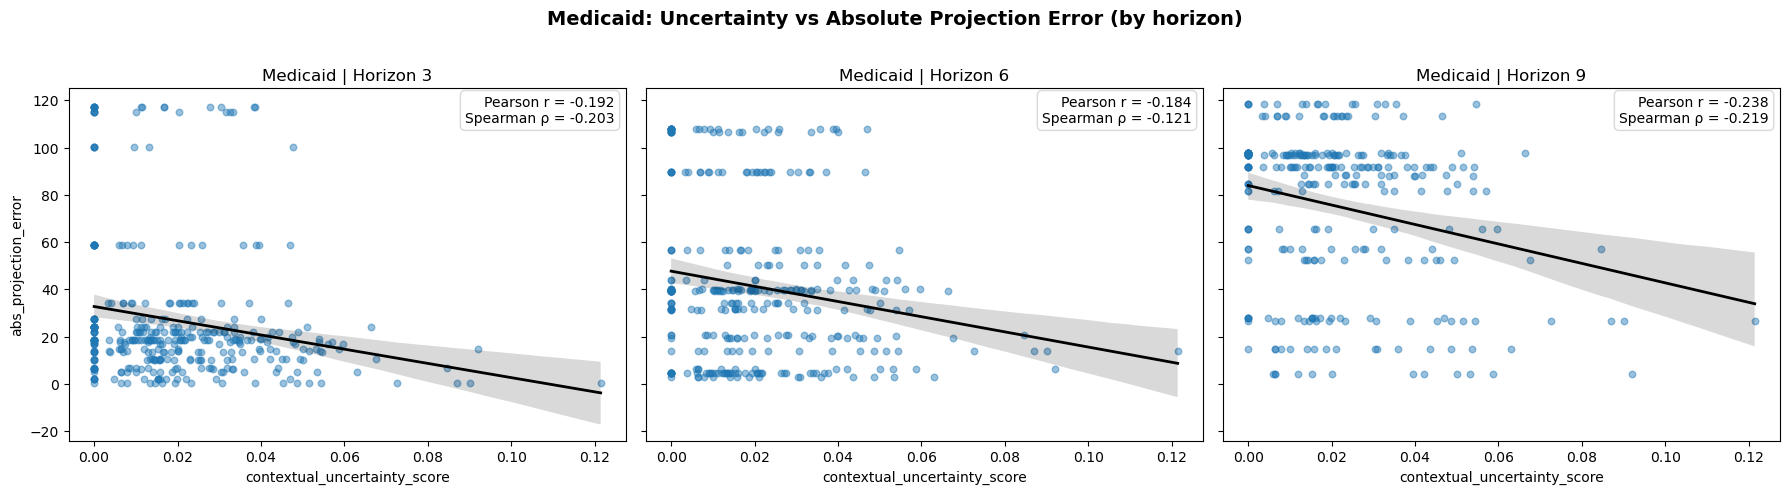

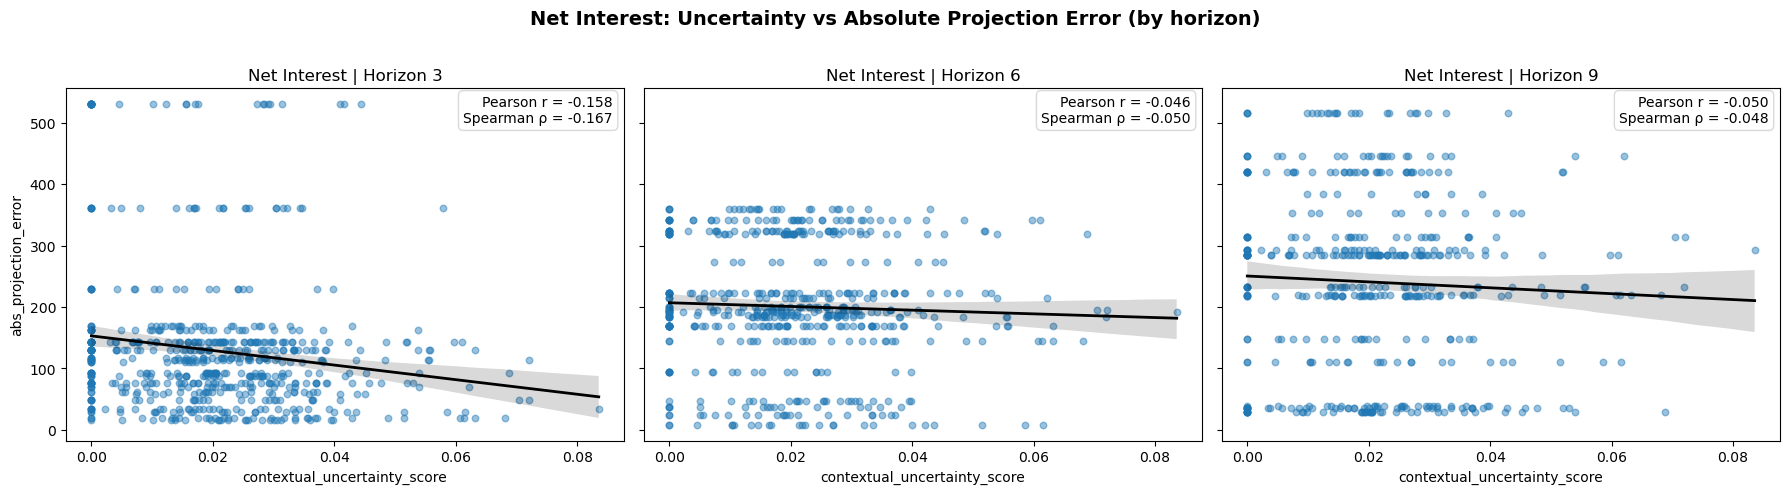

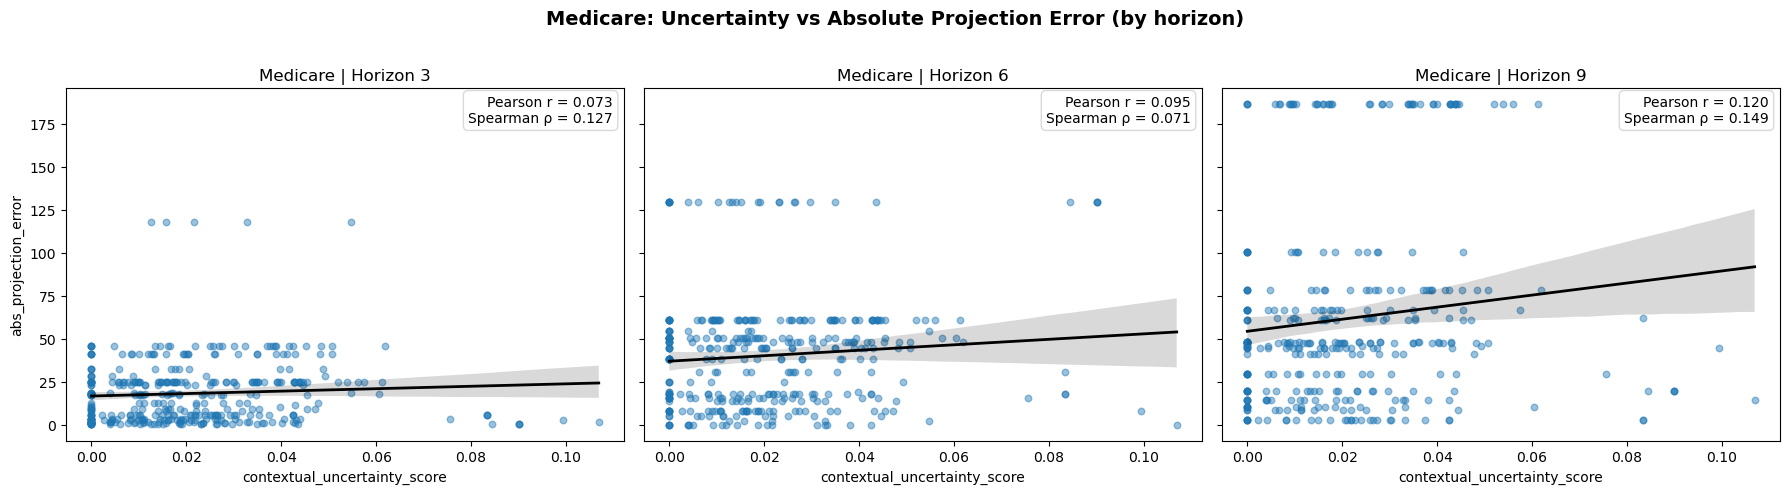

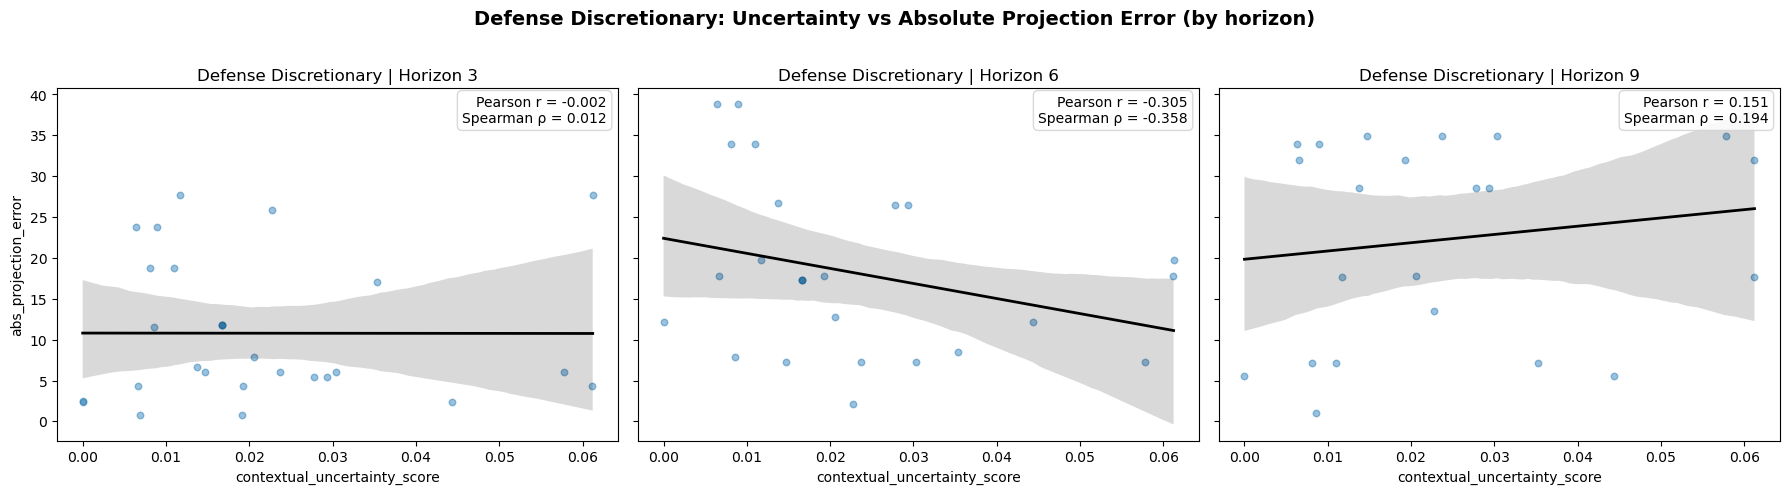

In [4]:
subs = merged_df["subcategory"].unique()

for sub in subs:
    fig, axes = plt.subplots(1, 3, figsize=(18, 4.8), sharey=True)

    for c, H in enumerate(horizons):
        ax = axes[c]

        d = merged_df[
            (merged_df["projection_horizon_years"] == H) &
            (merged_df["subcategory"] == sub)
        ].dropna(subset=["contextual_uncertainty_score", "abs_projection_error"])

        if d.empty or d["contextual_uncertainty_score"].nunique() < 2 or d["abs_projection_error"].nunique() < 2:
            ax.set_title(f"{sub.title()} | Horizon {H} (no/low variation)")
            ax.axis("off")
            continue

        # correlation (Spearman + Pearson)
        pearson_r, pearson_p = stats.pearsonr(d["contextual_uncertainty_score"], d["abs_projection_error"])
        spearman_rho, spearman_p = stats.spearmanr(d["contextual_uncertainty_score"], d["abs_projection_error"])

        # plot
        sns.regplot(
            data=d,
            x="contextual_uncertainty_score",
            y="abs_projection_error",
            scatter_kws={"alpha": 0.45, "s": 22},
            line_kws={"color": "black", "linewidth": 2},
            ax=ax
        )

        ax.set_title(f"{sub.title()} | Horizon {H}")
        ax.set_xlabel("contextual_uncertainty_score")
        ax.set_ylabel("abs_projection_error" if c == 0 else "")

        # annotation in top-right
        txt = (
            f"Pearson r = {pearson_r:.3f}\n"
            f"Spearman ρ = {spearman_rho:.3f}"
        )
        ax.text(
            0.98, 0.98, txt,
            transform=ax.transAxes,
            ha="right", va="top",
            fontsize=10,
            bbox=dict(boxstyle="round,pad=0.35", facecolor="white", alpha=0.85, edgecolor="lightgray")
        )

    plt.suptitle(f"{sub.title()}: Uncertainty vs Absolute Projection Error (by horizon)", y=1.02, fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.show()

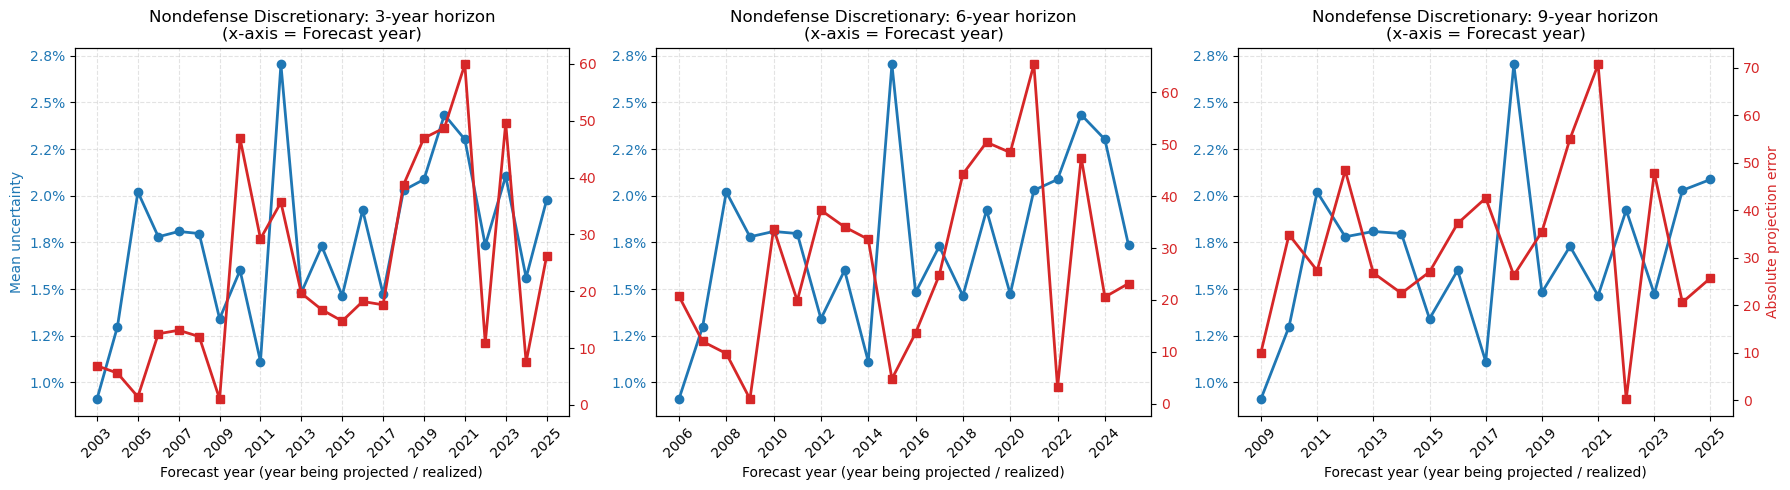

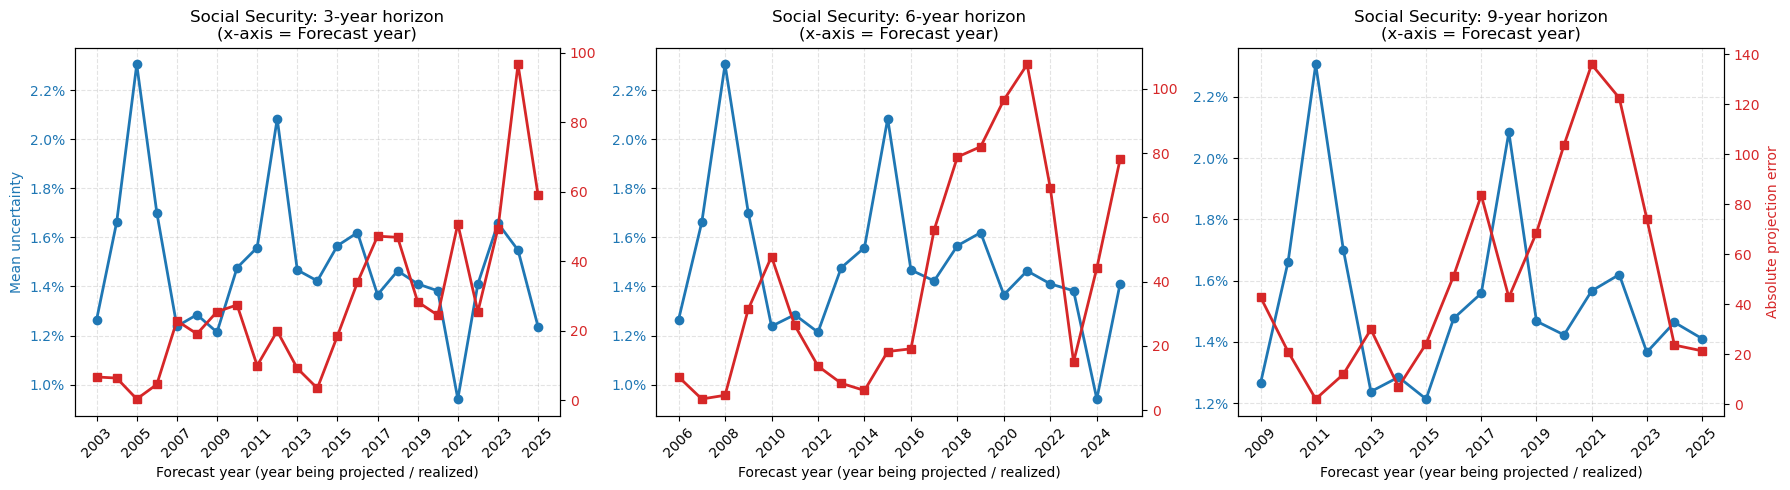

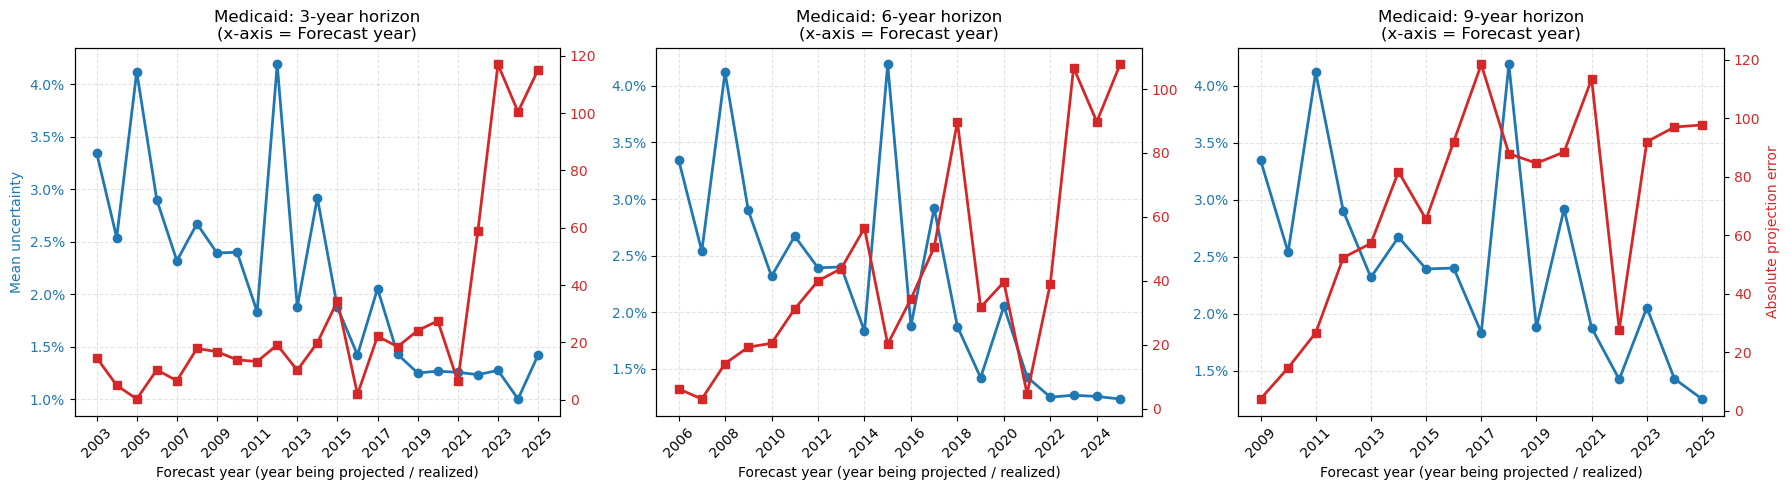

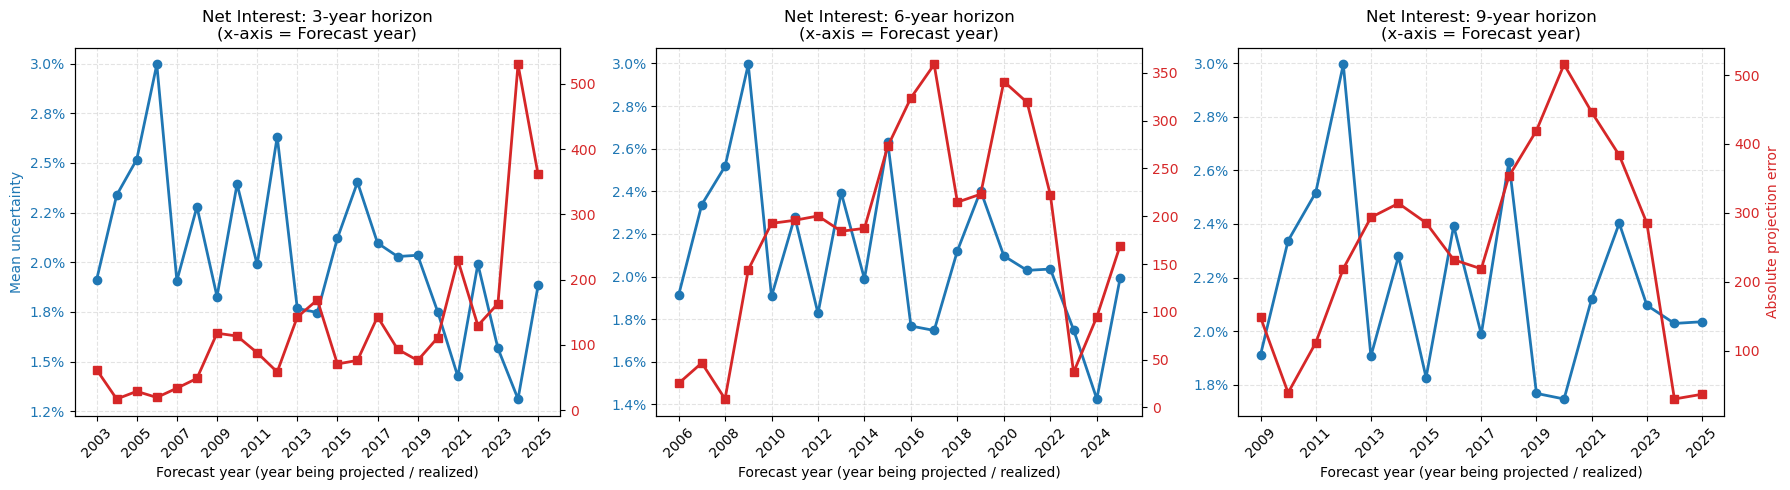

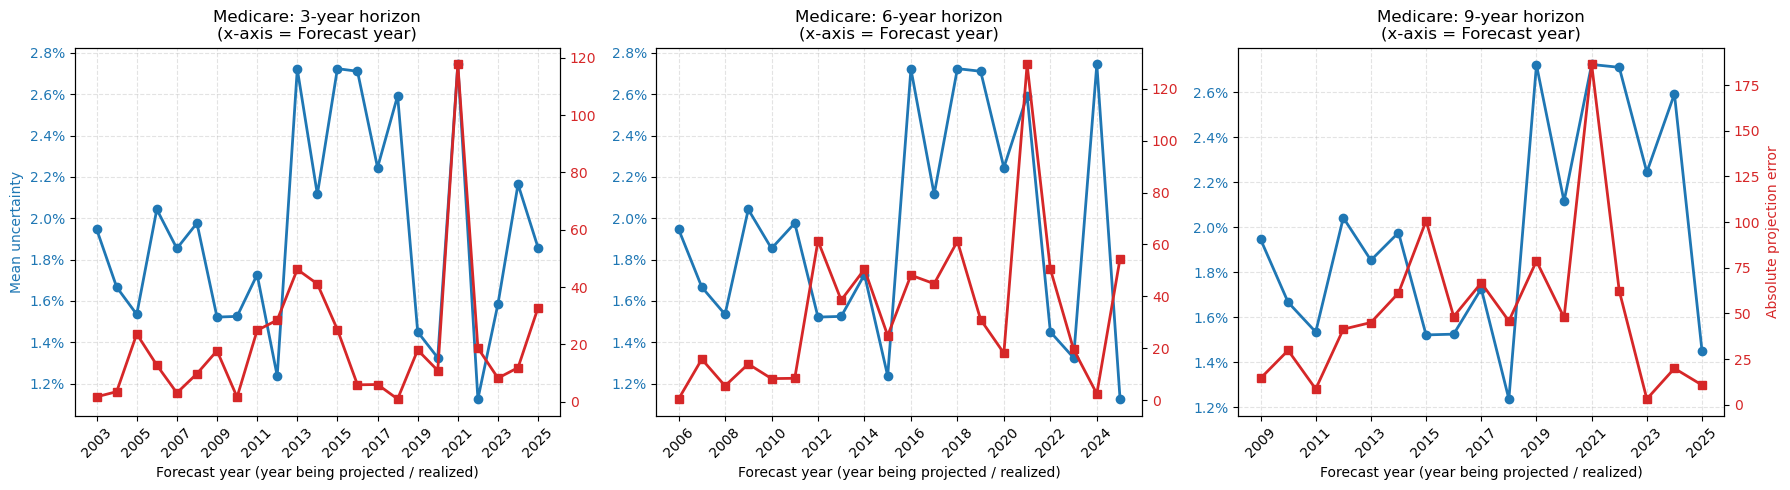

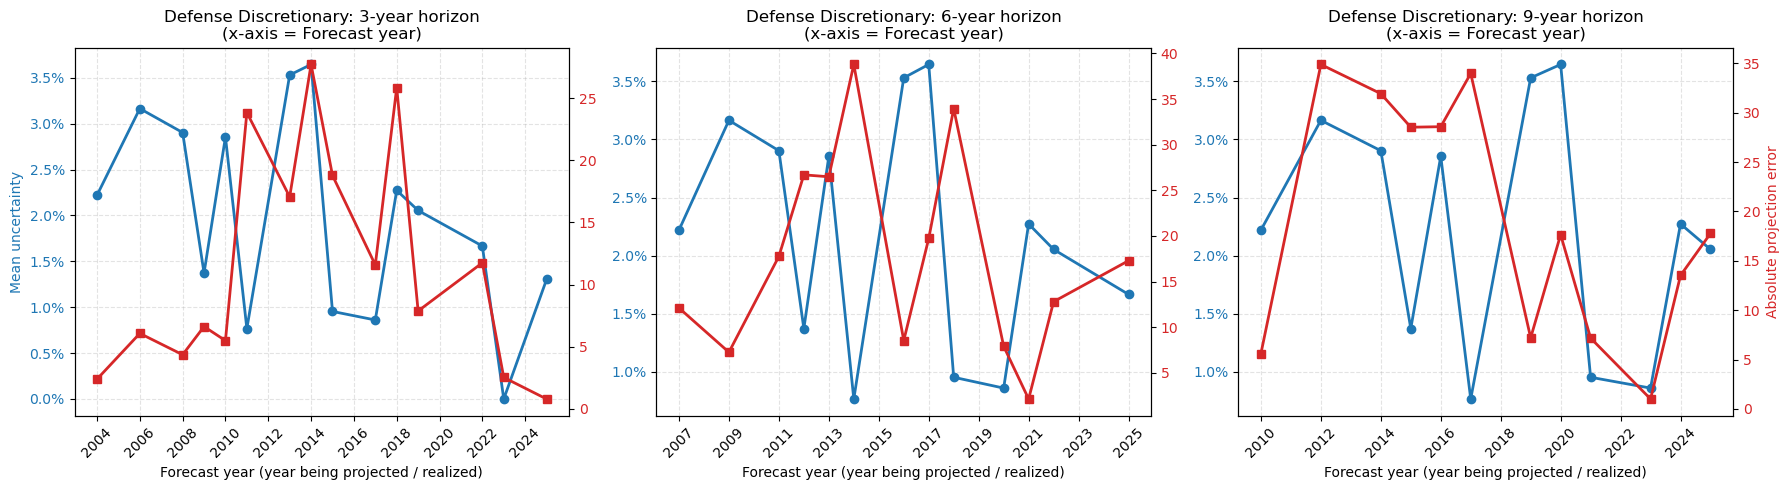

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

def plot_uncertainty_vs_error_by_forecast_year_from_merged(
    merged_df,
    program="medicaid",
    horizons=(3, 6, 9),
    score_col="contextual_uncertainty_score",
    err_col="abs_projection_error",
    show_uncertainty_as_percent=True,
    year_tick_step=2,
):
    d0 = merged_df.copy()

    # normalize labels
    d0["subcategory"] = d0["subcategory"].astype(str).str.strip().str.lower()
    program = str(program).strip().lower()

    # filter
    d0 = d0[d0["subcategory"].eq(program)].copy()
    d0 = d0.dropna(subset=["report_year", score_col, err_col, "projection_horizon_years"])

    d0["report_year"] = pd.to_numeric(d0["report_year"], errors="coerce")
    d0["projection_horizon_years"] = pd.to_numeric(d0["projection_horizon_years"], errors="coerce")
    d0 = d0.dropna(subset=["report_year", "projection_horizon_years"])

    d0["report_year"] = d0["report_year"].astype(int)
    d0["projection_horizon_years"] = d0["projection_horizon_years"].astype(int)

    # NEW: forecast year (year being forecast / realized)
    d0["forecast_year"] = d0["report_year"] + d0["projection_horizon_years"]

    fig, axes = plt.subplots(1, len(horizons), figsize=(18, 5), sharex=False)
    if len(horizons) == 1:
        axes = [axes]

    # formatters
    unc_fmt = FuncFormatter(lambda y, _: f"{100*y:.1f}%") if show_uncertainty_as_percent else FuncFormatter(lambda y, _: f"{y:.3f}")
    err_fmt = FuncFormatter(lambda y, _: f"{y:,.0f}")

    for i, H in enumerate(horizons):
        ax = axes[i]

        d = d0[d0["projection_horizon_years"].eq(H)].copy()
        if d.empty:
            ax.set_title(f"{program.title()}: Horizon {H} (no data)")
            ax.axis("off")
            continue

        # Aggregate to FORECAST YEAR (not report year)
        plot_df = (
            d.groupby("forecast_year", as_index=False)
             .agg(
                 mean_uncertainty=(score_col, "mean"),
                 paragraph_count=(score_col, "size"),
                 abs_projection_error=(err_col, "mean"),
                 mean_baseline_year=("report_year", "mean"),  # for debugging/interpretation
             )
             .sort_values("forecast_year")
        )

        # Left axis: uncertainty
        ax.plot(plot_df["forecast_year"], plot_df["mean_uncertainty"],
                marker="o", linewidth=2, color="#1f77b4")
        ax.set_title(f"{program.title()}: {H}-year horizon\n(x-axis = Forecast year)")
        ax.set_xlabel("Forecast year (year being projected / realized)")
        if i == 0:
            ax.set_ylabel("Mean uncertainty", color="#1f77b4")
        ax.tick_params(axis="y", labelcolor="#1f77b4")
        ax.yaxis.set_major_formatter(unc_fmt)
        ax.grid(True, linestyle="--", alpha=0.35)

        # X ticks
        years = plot_df["forecast_year"].to_numpy()
        if len(years) > 0:
            start = int(years.min())
            end = int(years.max())
            ax.set_xticks(list(range(start, end + 1, year_tick_step)))
        ax.tick_params(axis="x", rotation=45)

        # Right axis: abs error
        ax2 = ax.twinx()
        ax2.plot(plot_df["forecast_year"], plot_df["abs_projection_error"],
                 marker="s", linewidth=2, color="#d62728")
        if i == len(horizons) - 1:
            ax2.set_ylabel("Absolute projection error", color="#d62728")
        ax2.tick_params(axis="y", labelcolor="#d62728")
        ax2.yaxis.set_major_formatter(err_fmt)

    plt.tight_layout()
    plt.show()

for sub in subs:

    # Medicaid
    plot_uncertainty_vs_error_by_forecast_year_from_merged(
        merged_df=merged_df, program=sub, horizons=horizons, show_uncertainty_as_percent=True
    )
    
